# 10 · Classic time-series analyses

Use Airline Passengers, Nile flow and Mauna Loa CO₂ to distinguish serial dependence, trend and seasonality.

**Execution:** the default walkthrough reads checked saved app results, so it needs no live download or MCMC run.
Install this repository and the shared `bestfit-plots` package as described in the [README](../README.md).
To repeat an analysis, first build the pinned .NET runtime, set `RUN_ANALYSES = True`, and run the notebook in a fresh kernel.
The rerun retains the source priors, seeds, sampling settings and probability ordinates; receipts are saved under `output/reruns/`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
from IPython.display import display
from bestfit_examples.project_data import load_project
from bestfit_examples.data import input_inventory, series_inventory
from bestfit_examples.results import saved_case
from bestfit_examples.presentation import (case_metrics, case_provenance, compare_frequency,
    composite_weights, trend_ownership, uncertain_observations)
%matplotlib inline
RUN_ANALYSES = False  # True: rerun the saved analysis and its dependencies at full original settings.

## Airline Passengers
The source has 144 monthly observations for 1949–1960 and a saved ARIMA(1,1,1) configuration.
Keep the original training, transformation, seasonal and prediction settings visible. The app shades training and held-out prediction regions separately, meeting at the last training observation.
Airline trains on 120 of 144 values. `ForecastingTimeSteps=0`, so the final 24 values are a held-out prediction region rather than a future forecast.
The full-settings rerun audit flagged Airline sampler convergence: the largest R-hat is about 1.26 and the smallest ESS about 52.
Read this example as a model and diagnostic walkthrough; completion does not establish a reliable forecast. The [run-quality report](../validation/run-quality-summary.json) retains the parameter-level findings.

,Series,Route,Type,Unit,Records,Start,End,Missing
0,Airline Passengers,Manual,DailyDischarge,Passengers (thousands),144,1949-01-01T00:00:00.0000000,1960-12-01T00:00:00.0000000,0
1,Nile River Flows,Manual,DailyDischarge,Flow (10⁸ m³),100,1897-01-01T00:00:00.0000000,1996-01-01T00:00:00.0000000,0
2,Mauna Loa CO2,Manual,DailyDischarge,CO2 (ppm),790,1958-03-01T00:00:00.0000000,2023-12-01T00:00:00.0000000,0


,Setting,Saved choice
0,Analysis,ARIMAXAnalysis
1,TimeSeriesData,Airline Passengers
2,ForecastingTimeSteps,0
3,BayesianAnalysis.Type,DEMCzs
4,BayesianAnalysis.NumberOfChains,8
5,BayesianAnalysis.ThinningInterval,40
6,BayesianAnalysis.WarmupIterations,1750
7,BayesianAnalysis.Iterations,3500
8,BayesianAnalysis.UseSimulationDefaults,True
9,BayesianAnalysis.PRNGSeed,12345


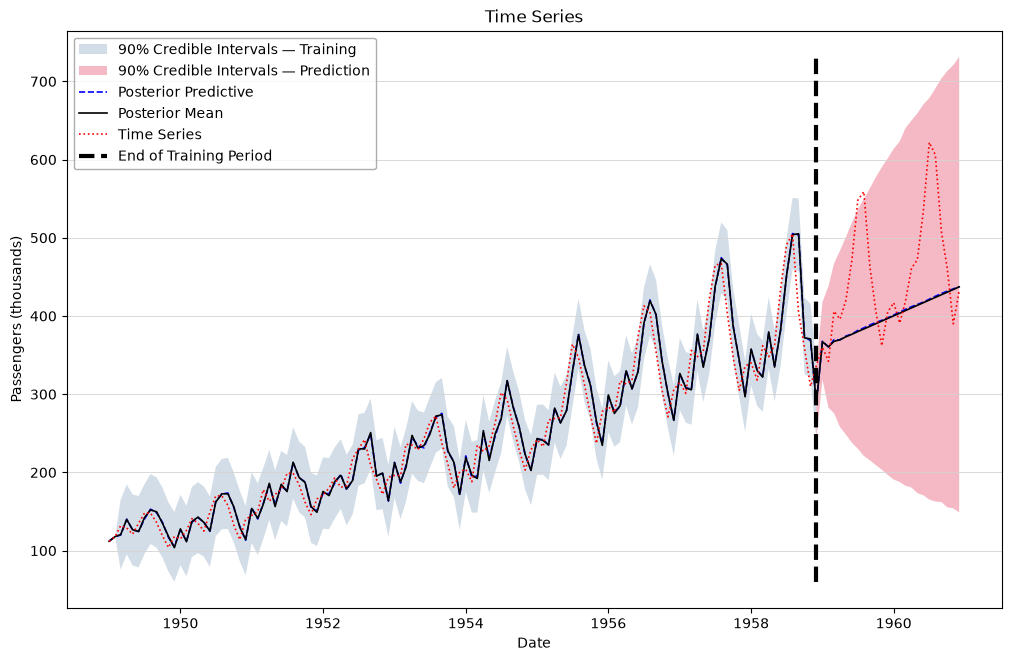

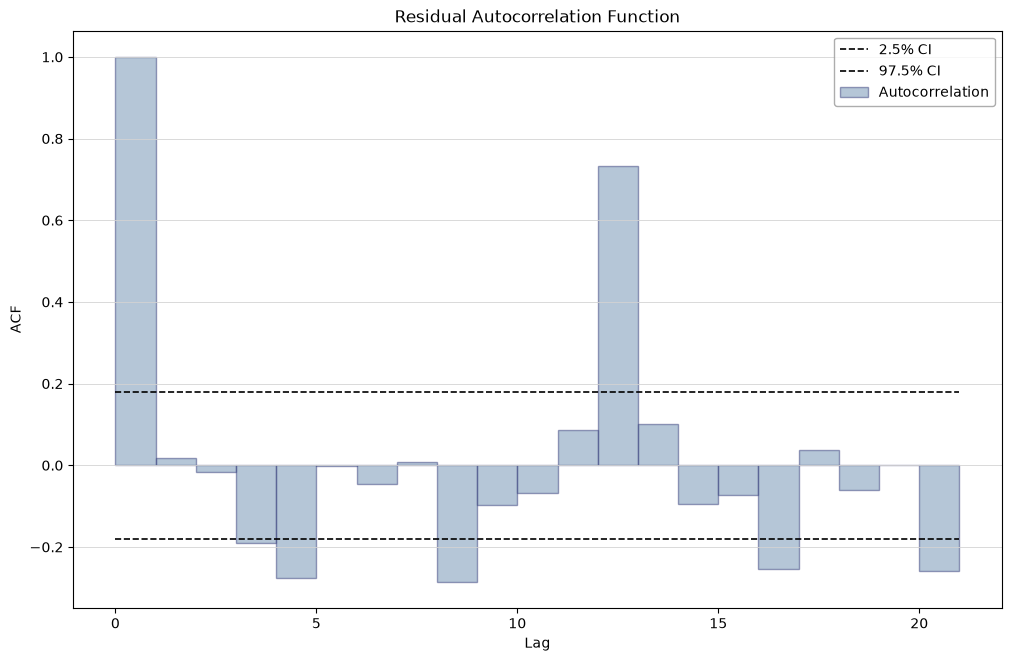

In [2]:
PROJECT = "classic-time-series-examples"
display(series_inventory(load_project(PROJECT)))
airline = saved_case(PROJECT, "Airline Passengers - TSA", run=RUN_ANALYSES)
display(airline.settings)
airline.show("series")
airline.show("residual_acf")

## Nile River flow
The saved model is ARIMA(1,1,0). A source discrepancy matters here: the `.bestfit` project dates the 100 values to 1897–1996,
while the source CSV dates the same values to 1871–1970. This walkthrough applies the documented 26-year **display-date correction** below.
It keeps the original project, values, model and saved results unchanged and records the correction in each date plot's metadata.
Nile uses saved ARIMA(1,1,0), trains on 80 of 100 values, and has `ForecastingTimeSteps=0`; its final 20 values are also held out, not future forecasts.
The app-compatible residual plot stores dates as numeric OLE Automation dates on a linear axis despite its response-unit label; the display correction shifts those encoded dates consistently without changing source timestamps or the model.

Nile source CSV dates, -26 years; values and fitted model retained


,Analysis,ARIMA,Training values,Total values,Held-out prediction values,Future forecast steps
0,Airline Passengers - TSA,"(1,1,1)",120,144,24,0
1,Nile River Flows - TSA,"(1,1,0)",80,100,20,0


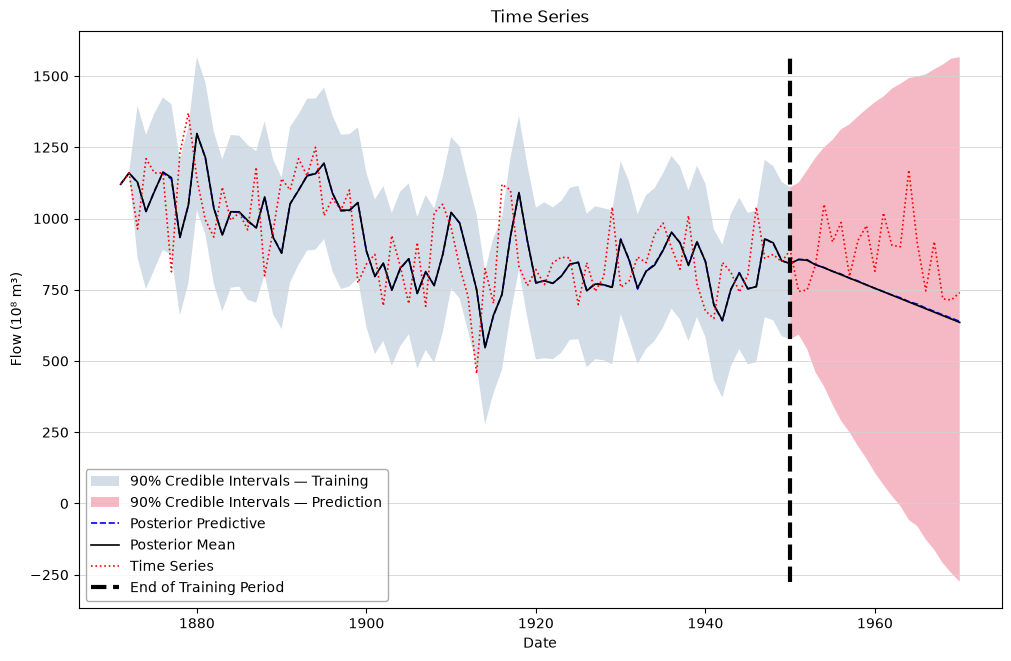

In [3]:
from bestfit_examples.presentation import corrected_nile_dates
nile = corrected_nile_dates(saved_case(PROJECT, "Nile River Flows - TSA", run=RUN_ANALYSES))
print(nile.data["dateCorrection"])
display(pd.DataFrame([{
    "Analysis": case.data["name"],
    "ARIMA": label,
    "Training values": int(case.data["settings"]["Model.TrainingTimeSteps"]),
    "Total values": total,
    "Held-out prediction values": total - int(case.data["settings"]["Model.TrainingTimeSteps"]),
    "Future forecast steps": int(case.data["settings"]["ForecastingTimeSteps"]),
} for case, label, total in [(airline, "(1,1,1)", 144), (nile, "(1,1,0)", 100)]]))
nile.show("series")

## Mauna Loa CO₂
This example uses a quadratic trend plus seasonality with no ARMA terms, rather than silently adding an autoregressive model.
Examine the remaining residual dependence and the distinction between extrapolating the saved trend and establishing a physical forecast model.
Airline passengers, Nile flow and atmospheric CO₂ are different responses with different likelihood scales; their fit metrics are retained per case and are not compared across rows.

,Setting,Saved choice
0,Analysis,ARIMAXAnalysis
1,TimeSeriesData,Mauna Loa CO2
2,ForecastingTimeSteps,0
3,BayesianAnalysis.Type,DEMCzs
4,BayesianAnalysis.NumberOfChains,12
5,BayesianAnalysis.ThinningInterval,60
6,BayesianAnalysis.WarmupIterations,1750
7,BayesianAnalysis.Iterations,3500
8,BayesianAnalysis.UseSimulationDefaults,True
9,BayesianAnalysis.PRNGSeed,12345


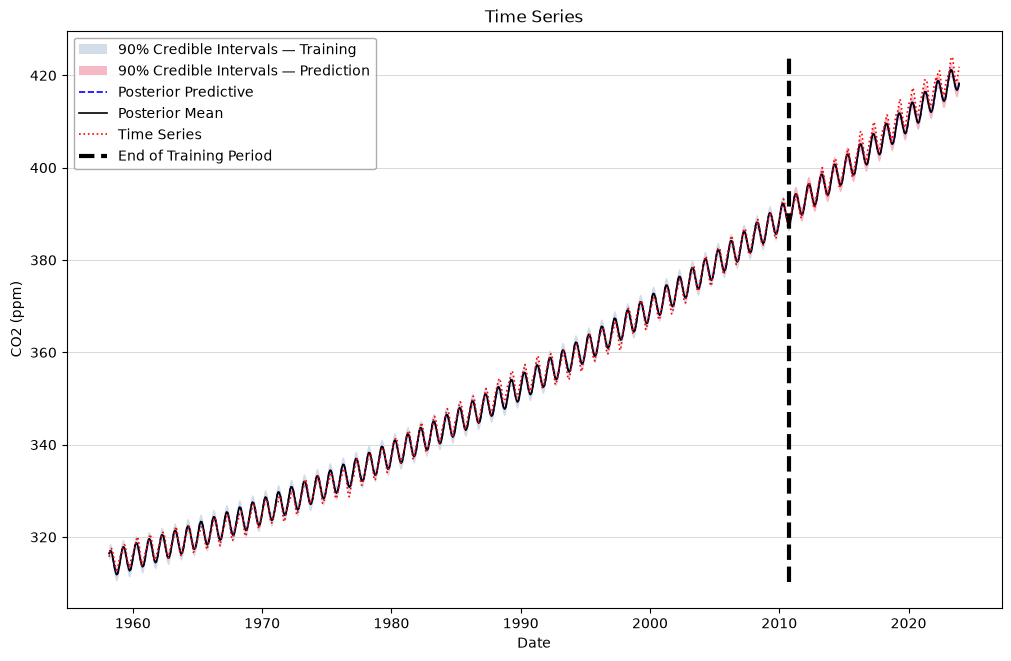

,Analysis,Input / response,Analysis type,AIC,BIC,DIC,RMSE,Metric note,Comparison scope
0,Airline Passengers - TSA,see saved dependencies,ARIMAXAnalysis,1100.857869,1112.007836,1115.279455,26.649927,,Descriptive only — rows may use different resp...
1,Nile River Flows - TSA,see saved dependencies,ARIMAXAnalysis,1016.998406,1024.144486,1016.318892,156.318431,,Descriptive only — rows may use different resp...
2,Mauna Loa - CO2,see saved dependencies,ARIMAXAnalysis,1720.316210,1747.009547,1720.183893,0.934708,,Descriptive only — rows may use different resp...


,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,Airline Passengers - TSA,saved-app,sha256:9eca00ee4cf0,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
1,Nile River Flows - TSA,saved-app,sha256:9eca00ee4cf0,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
2,Mauna Loa - CO2,saved-app,sha256:9eca00ee4cf0,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt


In [4]:
co2 = saved_case(PROJECT, "Mauna Loa - CO2", run=RUN_ANALYSES)
display(co2.settings)
co2.show("series")
display(case_metrics([airline, nile, co2]))
display(case_provenance([airline, nile, co2]))